In [9]:
import os
import re
import glob
import numpy as np
import matplotlib.pyplot as plt

# Konfiguracja stylu wykresów
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['figure.titlesize'] = 14
plt.rcParams['legend.fontsize'] = 11
plt.rcParams['grid.alpha'] = 0.5
plt.rcParams['figure.dpi'] = 120


In [10]:
def parse_perf_file(filepath):
    """Parsuje plik perf_cpu_stats.txt i zwraca słownik z metrykami."""
    with open(filepath, 'r') as f:
        content = f.read()

    data = {}
    time_m = re.search(r"([\d\.,]+)\s+seconds time elapsed", content)
    if time_m:
        data["time"] = float(time_m.group(1).replace(",", "."))

    cyc_m = re.search(r"([\d\s\.,]+)\s+cycles", content)
    if cyc_m:
        data["cycles"] = int(cyc_m.group(1).replace(" ", "").replace(".", "").replace(",", ""))

    inst_m = re.search(r"([\d\s\.,]+)\s+instructions", content)
    if inst_m:
        data["instructions"] = int(inst_m.group(1).replace(" ", "").replace(".", "").replace(",", ""))

    ipc_m = re.search(r"#\s+([\d\.,]+)\s+insn per cycle", content)
    if ipc_m:
        data["ipc"] = float(ipc_m.group(1).replace(",", "."))

    l1_miss_m = re.search(r"([\d\s\.,]+)\s+L1-dcache-load-misses", content)
    if l1_miss_m:
        data["l1_misses"] = int(l1_miss_m.group(1).replace(" ", "").replace(".", "").replace(",", ""))
    l1_load_m = re.search(r"([\d\s\.,]+)\s+L1-dcache-loads", content)
    if l1_load_m:
        data["l1_loads"] = int(l1_load_m.group(1).replace(" ", "").replace(".", "").replace(",", ""))
    if "l1_misses" in data and "l1_loads" in data and data["l1_loads"] > 0:
        data["l1_miss_rate"] = (data["l1_misses"] / data["l1_loads"]) * 100.0

    br_miss_m = re.search(r"([\d\s\.,]+)\s+branch-misses", content)
    if br_miss_m:
        data["branch_misses"] = int(br_miss_m.group(1).replace(" ", "").replace(".", "").replace(",", ""))
    br_load_m = re.search(r"([\d\s\.,]+)\s+branch-loads", content)
    if br_load_m:
        data["branch_loads"] = int(br_load_m.group(1).replace(" ", "").replace(".", "").replace(",", ""))
    if "branch_misses" in data and "branch_loads" in data and data["branch_loads"] > 0:
        data["branch_miss_rate"] = (data["branch_misses"] / data["branch_loads"]) * 100.0

    return data

# Ścieżka bazowa do logów (względem notatnika)
base_path = "hpc_logs" if os.path.exists("hpc_logs") else "plots/hpc_logs"

implementations = {
    "C-OMP": f"{base_path}/C-OMP/STAT/*/edupic_data/perf_cpu_stats.txt",
    "Go-Chunking": f"{base_path}/Go-Chunking/STAT/*/edupic_data/perf_cpu_stats.txt",
    "Go-Channels": f"{base_path}/Go-Channels/STAT/*/edupic_data/perf_cpu_stats.txt",
}

raw_data = {}
for name, pattern in implementations.items():
    raw_data[name] = {}
    for f in sorted(glob.glob(pattern)):
        run_name = os.path.basename(os.path.dirname(os.path.dirname(f)))
        raw_data[name][run_name] = parse_perf_file(f)

print("Wczytane serie pomiarowe:")
for k, v in raw_data.items():
    print(f"  {k}: {list(v.keys())}")


Wczytane serie pomiarowe:
  C-OMP: ['C_OMP_STAT-1', 'C_OMP_STAT-16', 'C_OMP_STAT-2', 'C_OMP_STAT-4', 'C_OMP_STAT-8']
  Go-Chunking: ['GO_CHUNKING_STAT-1-1', 'GO_CHUNKING_STAT-1-4', 'GO_CHUNKING_STAT-16-16', 'GO_CHUNKING_STAT-2-2', 'GO_CHUNKING_STAT-4-4', 'GO_CHUNKING_STAT-8-8']
  Go-Channels: ['CHANNELS_STAT-1-1', 'CHANNELS_STAT-1-4', 'CHANNELS_STAT-16-16', 'CHANNELS_STAT-2-2', 'CHANNELS_STAT-4-4', 'CHANNELS_STAT-8-8']


In [11]:
# Mapowanie rdzeni dla serii skalowania 1:1
scaling_cores = [1, 2, 4, 8, 16]

c_omp_map = {1: "C_OMP_STAT-1", 2: "C_OMP_STAT-2", 4: "C_OMP_STAT-4", 8: "C_OMP_STAT-8", 16: "C_OMP_STAT-16"}
go_chunk_map = {1: "GO_CHUNKING_STAT-1-1", 2: "GO_CHUNKING_STAT-2-2", 4: "GO_CHUNKING_STAT-4-4", 8: "GO_CHUNKING_STAT-8-8", 16: "GO_CHUNKING_STAT-16-16"}
go_chan_map = {1: "CHANNELS_STAT-1-1", 2: "CHANNELS_STAT-2-2", 4: "CHANNELS_STAT-4-4", 8: "CHANNELS_STAT-8-8", 16: "CHANNELS_STAT-16-16"}

series = {
    "C++ OpenMP": (c_omp_map, raw_data["C-OMP"], "#1f77b4", "o-"),
    "Go Chunking": (go_chunk_map, raw_data["Go-Chunking"], "#2ca02c", "s-"),
    "Go Channels": (go_chan_map, raw_data["Go-Channels"], "#ff7f0e", "^-"),
}

header = f"{'Implementacja':<15} | {'Rdzenie':<7} | {'Czas [s]':<10} | {'Speedup':<8} | {'IPC':<6} | {'Instrukcje [mld]':<16} | {'Branch Miss [%]':<16}"
print(header)
print("-" * len(header))

stats_summary = {}
for label, (mapping, d, color, style) in series.items():
    stats_summary[label] = {
        "cores": [], "time": [], "speedup": [], "efficiency": [],
        "ipc": [], "instructions": [], "cycles": [],
        "l1_miss_rate": [], "branch_miss_rate": []
    }
    t1 = d[mapping[1]]["time"]
    for c in scaling_cores:
        key = mapping[c]
        item = d[key]
        t = item["time"]
        sp = t1 / t
        eff = sp / c * 100.0
        
        stats_summary[label]["cores"].append(c)
        stats_summary[label]["time"].append(t)
        stats_summary[label]["speedup"].append(sp)
        stats_summary[label]["efficiency"].append(eff)
        stats_summary[label]["ipc"].append(item.get("ipc", 0))
        stats_summary[label]["instructions"].append(item.get("instructions", 0) / 1e9)
        stats_summary[label]["cycles"].append(item.get("cycles", 0) / 1e9)
        stats_summary[label]["l1_miss_rate"].append(item.get("l1_miss_rate", 0))
        stats_summary[label]["branch_miss_rate"].append(item.get("branch_miss_rate", 0))
        
        row = f"{label:<15} | {c:<7} | {t:<10.2f} | {sp:<8.2f} | {item.get('ipc', 0):<6.2f} | {item.get('instructions', 0)/1e9:<16.2f} | {item.get('branch_miss_rate', 0):<16.2f}"
        print(row)
    print("-" * len(header))


Implementacja   | Rdzenie | Czas [s]   | Speedup  | IPC    | Instrukcje [mld] | Branch Miss [%] 
------------------------------------------------------------------------------------------------
C++ OpenMP      | 1       | 263.82     | 1.00     | 2.96   | 2830.14          | 0.14            
C++ OpenMP      | 2       | 231.04     | 1.14     | 1.87   | 3135.63          | 0.16            
C++ OpenMP      | 4       | 128.76     | 2.05     | 1.83   | 3415.75          | 0.19            
C++ OpenMP      | 8       | 136.02     | 1.94     | 0.94   | 3706.17          | 0.21            
C++ OpenMP      | 16      | 105.76     | 2.49     | 0.66   | 4116.34          | 0.26            
------------------------------------------------------------------------------------------------
Go Chunking     | 1       | 379.11     | 1.00     | 4.16   | 5778.94          | 0.04            
Go Chunking     | 2       | 451.40     | 0.84     | 3.01   | 5790.01          | 0.05            
Go Chunking     | 4       | 22

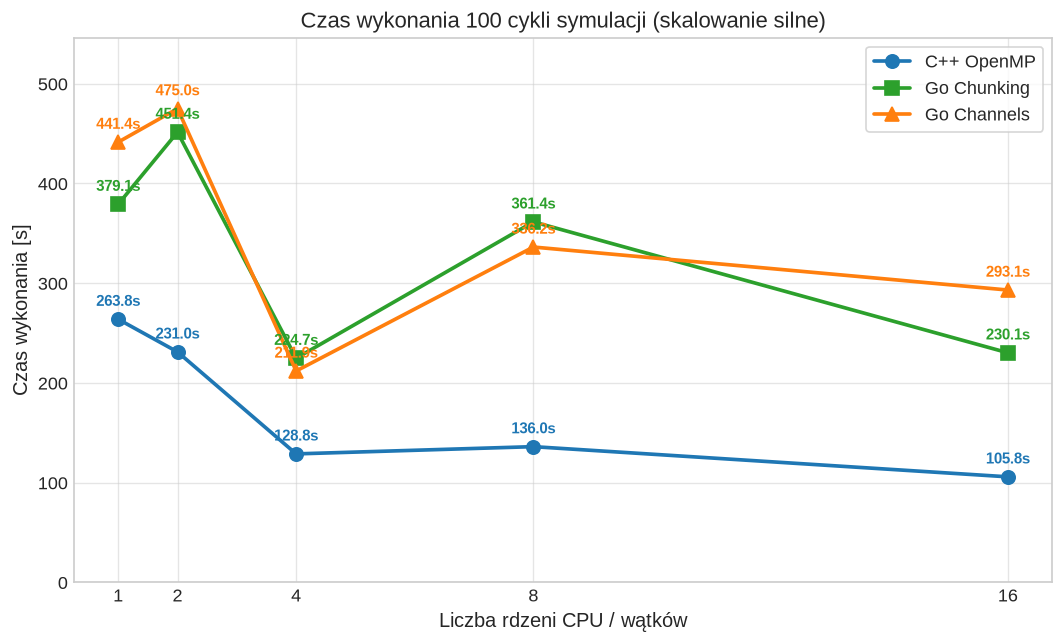

In [12]:
fig, ax = plt.subplots(figsize=(9, 5.5))

for label, (mapping, d, color, style) in series.items():
    cores = stats_summary[label]["cores"]
    times = stats_summary[label]["time"]
    ax.plot(cores, times, style, color=color, label=label, linewidth=2.2, markersize=8)
    for x, y in zip(cores, times):
        ax.annotate(f"{y:.1f}s", (x, y), textcoords="offset points", xytext=(0, 8),
                    ha="center", fontsize=9, fontweight="bold", color=color)

ax.set_xlabel("Liczba rdzeni CPU / wątków")
ax.set_ylabel("Czas wykonania [s]")
ax.set_title("Czas wykonania 100 cykli symulacji (skalowanie silne)")
ax.set_xticks(scaling_cores)
ax.set_ylim(bottom=0, top=max([max(stats_summary[l]["time"]) for l in stats_summary]) * 1.15)
ax.legend(frameon=True)
plt.tight_layout()
plt.show()


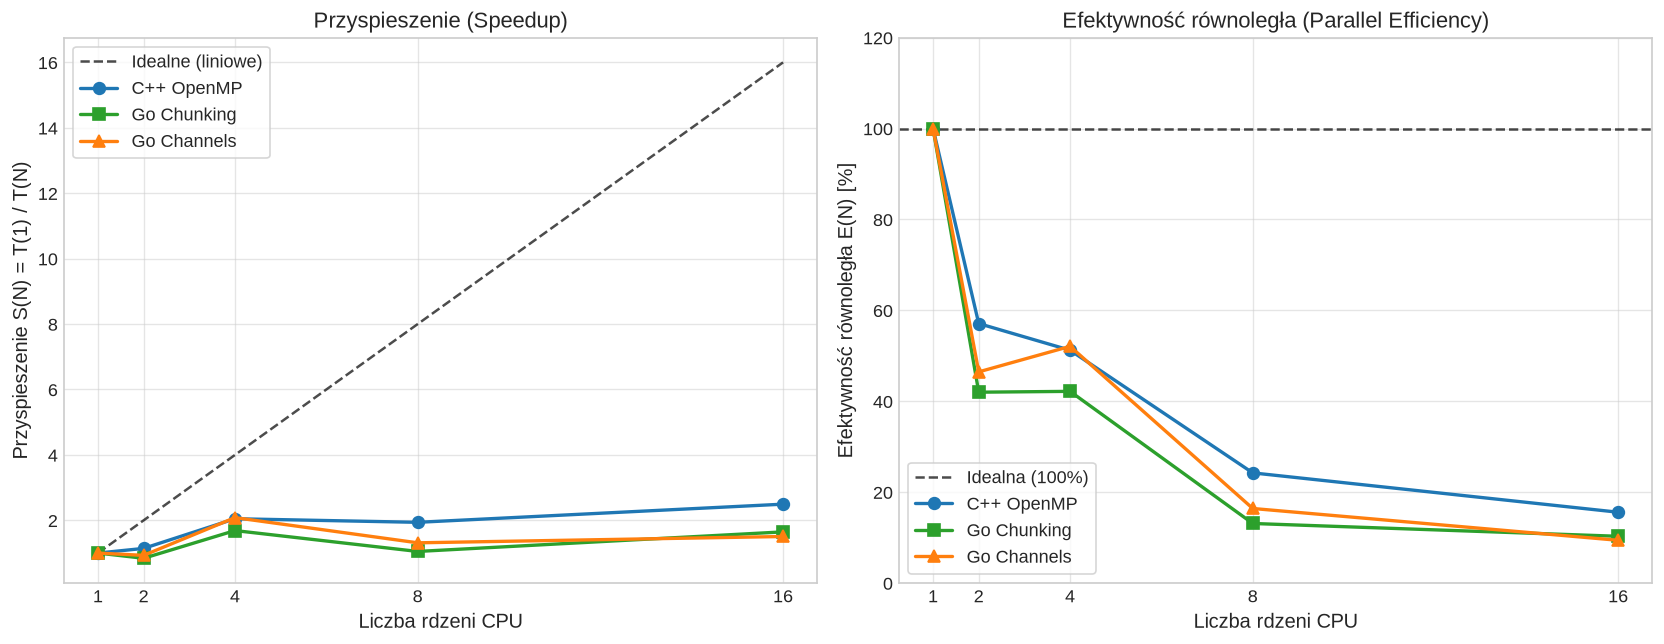

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# Subplot 1: Speedup
ax1.plot(scaling_cores, scaling_cores, "k--", label="Idealne (liniowe)", alpha=0.7, linewidth=1.5)
for label, (mapping, d, color, style) in series.items():
    cores = stats_summary[label]["cores"]
    sp = stats_summary[label]["speedup"]
    ax1.plot(cores, sp, style, color=color, label=label, linewidth=2, markersize=7)

ax1.set_xlabel("Liczba rdzeni CPU")
ax1.set_ylabel("Przyspieszenie S(N) = T(1) / T(N)")
ax1.set_title("Przyspieszenie (Speedup)")
ax1.set_xticks(scaling_cores)
ax1.legend(frameon=True)

# Subplot 2: Parallel Efficiency
ax2.axhline(100, color="k", linestyle="--", label="Idealna (100%)", alpha=0.7, linewidth=1.5)
for label, (mapping, d, color, style) in series.items():
    cores = stats_summary[label]["cores"]
    eff = stats_summary[label]["efficiency"]
    ax2.plot(cores, eff, style, color=color, label=label, linewidth=2, markersize=7)

ax2.set_xlabel("Liczba rdzeni CPU")
ax2.set_ylabel("Efektywność równoległa E(N) [%]")
ax2.set_title("Efektywność równoległa (Parallel Efficiency)")
ax2.set_xticks(scaling_cores)
ax2.set_ylim(0, 120)
ax2.legend(frameon=True)

plt.tight_layout()
plt.show()


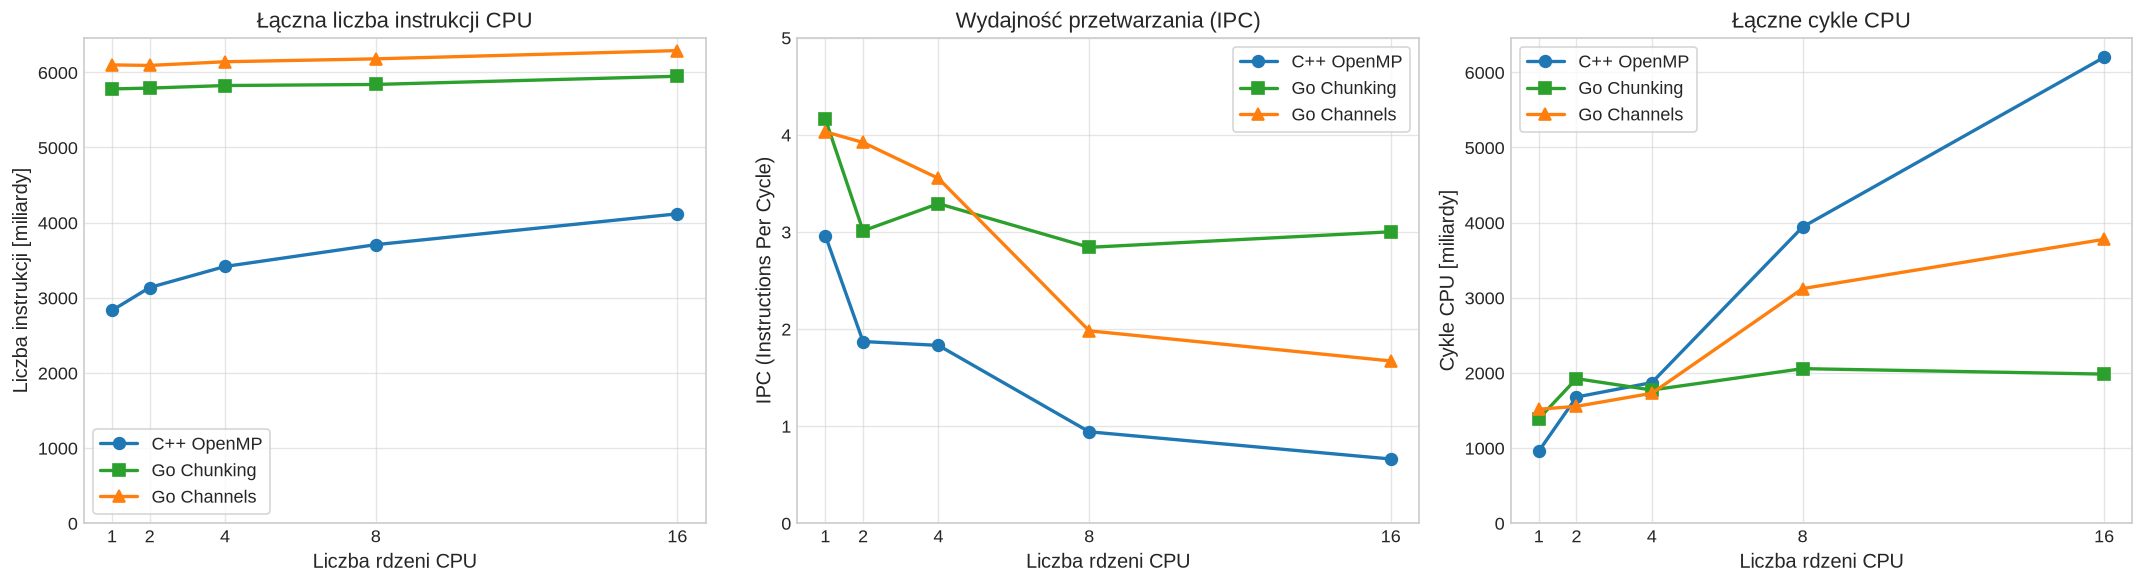

In [14]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# 1. Liczba instrukcji
for label, (mapping, d, color, style) in series.items():
    ax1.plot(scaling_cores, stats_summary[label]["instructions"], style, color=color, label=label, linewidth=2, markersize=7)
ax1.set_xlabel("Liczba rdzeni CPU")
ax1.set_ylabel("Liczba instrukcji [miliardy]")
ax1.set_title("Łączna liczba instrukcji CPU")
ax1.set_xticks(scaling_cores)
ax1.set_ylim(bottom=0)
ax1.legend(frameon=True)

# 2. IPC
for label, (mapping, d, color, style) in series.items():
    ax2.plot(scaling_cores, stats_summary[label]["ipc"], style, color=color, label=label, linewidth=2, markersize=7)
ax2.set_xlabel("Liczba rdzeni CPU")
ax2.set_ylabel("IPC (Instructions Per Cycle)")
ax2.set_title("Wydajność przetwarzania (IPC)")
ax2.set_xticks(scaling_cores)
ax2.set_ylim(bottom=0, top=5.0)
ax2.legend(frameon=True)

# 3. Cykle CPU
for label, (mapping, d, color, style) in series.items():
    ax3.plot(scaling_cores, stats_summary[label]["cycles"], style, color=color, label=label, linewidth=2, markersize=7)
ax3.set_xlabel("Liczba rdzeni CPU")
ax3.set_ylabel("Cykle CPU [miliardy]")
ax3.set_title("Łączne cykle CPU")
ax3.set_xticks(scaling_cores)
ax3.set_ylim(bottom=0)
ax3.legend(frameon=True)

plt.tight_layout()
plt.show()


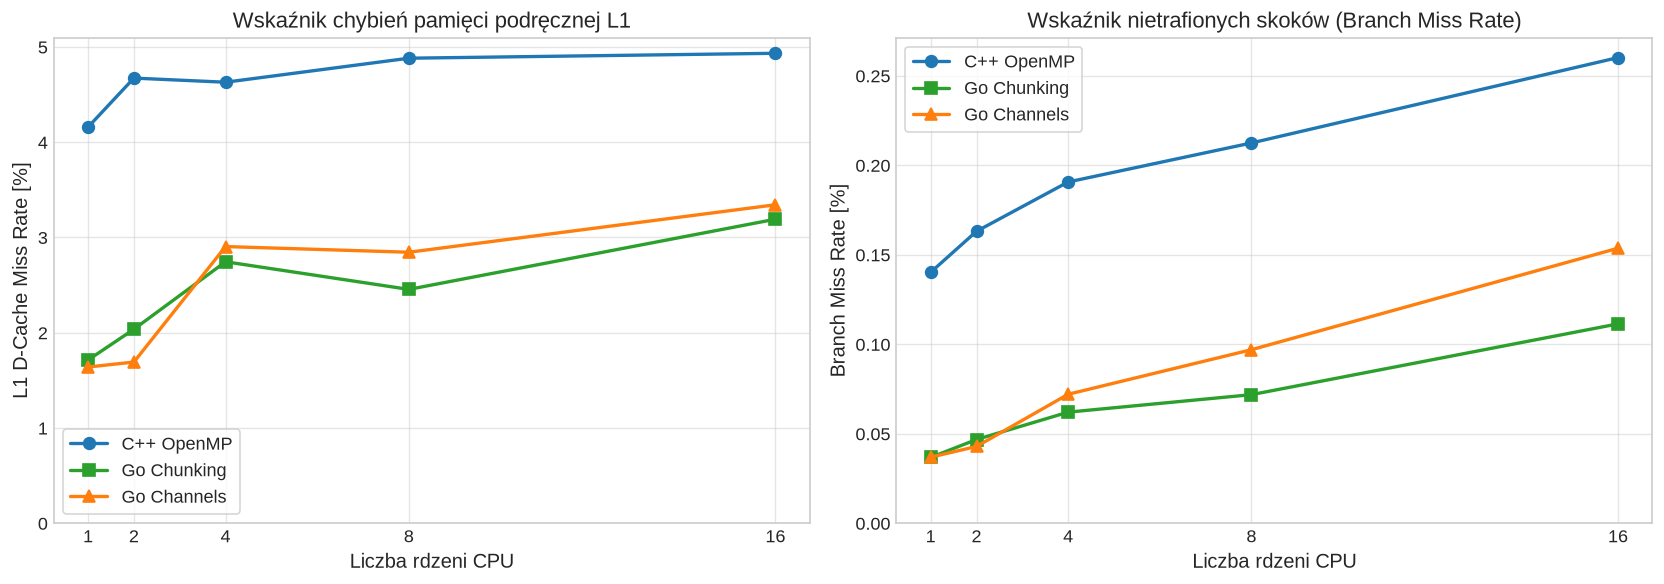

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 1. L1 Cache Miss Rate
for label, (mapping, d, color, style) in series.items():
    ax1.plot(scaling_cores, stats_summary[label]["l1_miss_rate"], style, color=color, label=label, linewidth=2, markersize=7)
ax1.set_xlabel("Liczba rdzeni CPU")
ax1.set_ylabel("L1 D-Cache Miss Rate [%]")
ax1.set_title("Wskaźnik chybień pamięci podręcznej L1")
ax1.set_xticks(scaling_cores)
ax1.set_ylim(bottom=0)
ax1.legend(frameon=True)

# 2. Branch Miss Rate
for label, (mapping, d, color, style) in series.items():
    ax2.plot(scaling_cores, stats_summary[label]["branch_miss_rate"], style, color=color, label=label, linewidth=2, markersize=7)
ax2.set_xlabel("Liczba rdzeni CPU")
ax2.set_ylabel("Branch Miss Rate [%]")
ax2.set_title("Wskaźnik nietrafionych skoków (Branch Miss Rate)")
ax2.set_xticks(scaling_cores)
ax2.set_ylim(bottom=0)
ax2.legend(frameon=True)

plt.tight_layout()
plt.show()


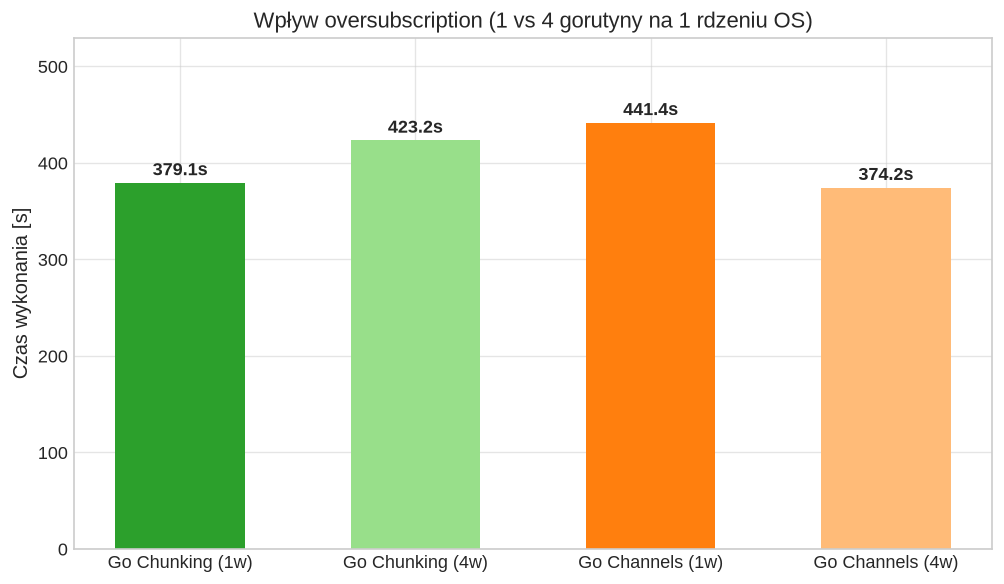

In [16]:
# Porównanie 1 rdzeń: 1 gorutyna vs 4 gorutyny
oversub_data = {
    "Go Chunking (1w)": raw_data["Go-Chunking"]["GO_CHUNKING_STAT-1-1"]["time"],
    "Go Chunking (4w)": raw_data["Go-Chunking"]["GO_CHUNKING_STAT-1-4"]["time"],
    "Go Channels (1w)": raw_data["Go-Channels"]["CHANNELS_STAT-1-1"]["time"],
    "Go Channels (4w)": raw_data["Go-Channels"]["CHANNELS_STAT-1-4"]["time"],
}

fig, ax = plt.subplots(figsize=(8.5, 5))
bars = ax.bar(list(oversub_data.keys()), list(oversub_data.values()), color=["#2ca02c", "#98df8a", "#ff7f0e", "#ffbb78"], width=0.55)

for bar in bars:
    y = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, y + 8, f"{y:.1f}s", ha="center", fontweight="bold")

ax.set_ylabel("Czas wykonania [s]")
ax.set_title("Wpływ oversubscription (1 vs 4 gorutyny na 1 rdzeniu OS)")
ax.set_ylim(0, max(oversub_data.values()) * 1.2)
plt.tight_layout()
plt.show()
